# Week 4 – Day 1: Sequential Modeling with RNN, LSTM & GRU
## Sentiment Analysis on IMDb Movie Reviews (Complete Pipeline)

# Table of Contents

- [Week 4 – Day 1: Sequential Modeling with RNN, LSTM & GRU](#week-4--day-1-sequential-modeling-with-rnn-lstm--gru)
  - [Sentiment Analysis on IMDb Movie Reviews (Complete Pipeline)](#sentiment-analysis-on-imdb-movie-reviews-complete-pipeline)
  - [Step 1: Dataset Loading & Exploration](#step-1-dataset-loading--exploration)
  - [Step 2: Text Preprocessing](#step-2-text-preprocessing)
  - [Step 3: Models Banana — Simple RNN, LSTM, GRU](#step-3-models-banana--simple-rnn-lstm-gru)
  - [Step 4: Training](#step-4-training)
  - [Step 5: Evaluation](#step-5-evaluation)
  - [Step 6: Comparison Table & Analysis](#step-6-comparison-table--analysis)
    - [Analysis](#analysis)
 

**Dataset Source:** [IMDB Dataset of 50K Movie Reviews (Kaggle)](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)



In [1]:
import re
import time
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


## 📂 Dataset Loading & Exploration

The IMDb Movie Reviews dataset is loaded to build a sentiment analysis model. It contains movie reviews along with their corresponding sentiment labels (positive or negative). Before training the models, the dataset is explored to understand its structure, identify missing values, and verify that the data has been loaded correctly. This step ensures the quality and reliability of the input data.---


In [2]:
df = pd.read_csv("IMDB Dataset.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})
print(df["label"].value_counts())

label
1    25000
0    25000
Name: count, dtype: int64


In [4]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Training samples: 40000
Testing samples: 10000


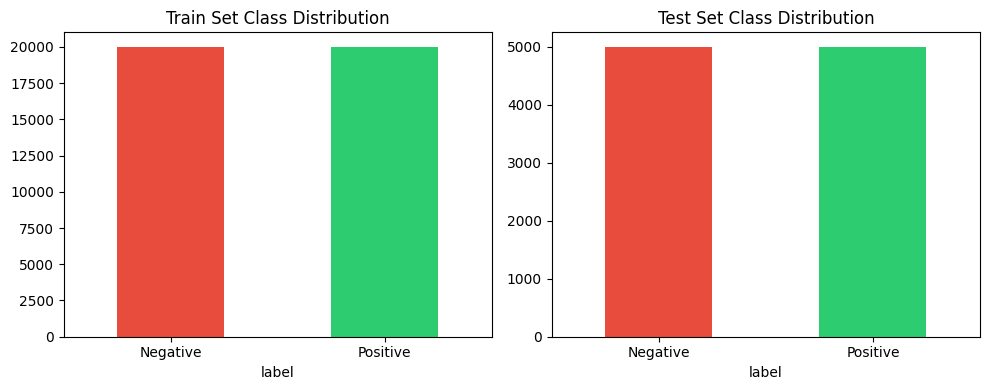

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train_df["label"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Train Set Class Distribution")
axes[0].set_xticklabels(["Negative", "Positive"], rotation=0)

test_df["label"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["#e74c3c", "#2ecc71"])
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xticklabels(["Negative", "Positive"], rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=100)
plt.show()

count    40000.000000
mean       231.362750
std        171.083908
min          4.000000
25%        126.000000
50%        173.000000
75%        282.000000
max       2470.000000
Name: review, dtype: float64


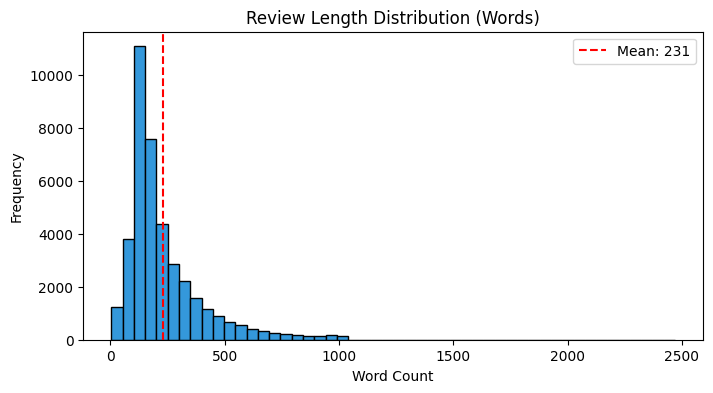

In [6]:
word_counts = train_df["review"].apply(lambda x: len(x.split()))
print(word_counts.describe())

plt.figure(figsize=(8,4))
plt.hist(word_counts, bins=50, color="#3498db", edgecolor="black")
plt.axvline(word_counts.mean(), color="red", linestyle="--", label=f"Mean: {word_counts.mean():.0f}")
plt.title("Review Length Distribution (Words)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("review_length_distribution.png", dpi=100)
plt.show()

## Text Preprocessing

Text preprocessing is an essential step in Natural Language Processing (NLP). Raw text often contains punctuation, HTML tags, special characters, and inconsistent capitalization. Cleaning the text removes unnecessary information and converts it into a consistent format, enabling deep learning models to learn meaningful patterns more effectively.---


In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df["clean_review"] = train_df["review"].apply(clean_text)
test_df["clean_review"] = test_df["review"].apply(clean_text)

print("Before:", train_df["review"].iloc[0][:200])
print("\nAfter: ", train_df["clean_review"].iloc[0][:200])

Before: I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch o

After:  i caught this little gem totally by accident back in or i was at a revival theatre to see two old silly sci fi movies the theatre was packed full and with no warning they showed a bunch of sci fi shor


In [8]:
train_df["tokens"] = train_df["clean_review"].apply(str.split)
test_df["tokens"] = test_df["clean_review"].apply(str.split)

print(train_df["tokens"].iloc[0][:15])

['i', 'caught', 'this', 'little', 'gem', 'totally', 'by', 'accident', 'back', 'in', 'or', 'i', 'was', 'at', 'a']


In [9]:
VOCAB_SIZE = 10000

counter = Counter()
for tokens in train_df["tokens"]:
    counter.update(tokens)

most_common = counter.most_common(VOCAB_SIZE - 2)
vocab = {"<PAD>": 0, "<UNK>": 1}
for idx, (word, freq) in enumerate(most_common, start=2):
    vocab[word] = idx

print("Vocabulary size:", len(vocab))

Vocabulary size: 10000


#  Tokenization

Tokenization is the process of splitting text into individual words or tokens. Each token represents a meaningful unit of the sentence, allowing the neural network to process textual information in numerical form.

In [10]:
def tokens_to_sequence(tokens, vocab):
    return [vocab.get(w, vocab["<UNK>"]) for w in tokens]

MAX_LEN = 120

def pad_sequence(seq, max_len):
    if len(seq) >= max_len:
        return seq[:max_len]
    return [0] * (max_len - len(seq)) + seq

train_df["sequence"] = train_df["tokens"].apply(lambda t: pad_sequence(tokens_to_sequence(t, vocab), MAX_LEN))
test_df["sequence"] = test_df["tokens"].apply(lambda t: pad_sequence(tokens_to_sequence(t, vocab), MAX_LEN))

print("Padded sequence length:", len(train_df["sequence"].iloc[0]))
print(train_df["sequence"].iloc[0][:20])

Padded sequence length: 120
[10, 1031, 11, 121, 1480, 453, 34, 1592, 145, 9, 41, 10, 14, 32, 4, 8622, 1636, 6, 66, 107]


#  DataLoader Preparation

The processed sequences and labels are converted into PyTorch tensors and loaded using DataLoader. This allows the dataset to be divided into mini-batches, improving training efficiency and memory management.

In [11]:
class IMDbDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(list(sequences), dtype=torch.long)
        self.labels = torch.tensor(list(labels), dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

BATCH_SIZE = 64

train_dataset = IMDbDataset(train_df["sequence"], train_df["label"])
test_dataset = IMDbDataset(test_df["sequence"], test_df["label"])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader), "| Test batches:", len(test_loader))

with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

Train batches: 625 | Test batches: 157


---
## Step 3: Models Banana — Simple RNN, LSTM, GRU

To ensure a fair comparison, all three models use the same architecture, differing only in the recurrent layer (RNN, LSTM, or GRU). The common architecture is:
 
Embedding → Recurrent Layer → Fully Connected Layer → Sigmoid Output for binary sentiment classification

# 🧠 Recurrent Neural Network (RNN)

A Recurrent Neural Network (RNN) is designed for sequential data such as text, speech, and time-series data. Unlike traditional neural networks, an RNN remembers information from previous time steps using a hidden state. However, it suffers from the vanishing gradient problem when processing long sequences.

**Formula**

hₜ = tanh(Wₓxₜ + Wₕhₜ₋₁ + b)

where:
- hₜ = current hidden state
- xₜ = current input
- W = weight matrices
- b = bias

# 🔐 Long Short-Term Memory (LSTM)

Long Short-Term Memory (LSTM) is an advanced version of RNN designed to overcome the vanishing gradient problem. It introduces memory cells and gating mechanisms that allow the model to retain important information while discarding irrelevant information. This makes LSTM highly effective for long text sequences.

**Key Gates**
- Forget Gate
- Input Gate
- Output Gate

**Cell State Update**

Cₜ = fₜ ⊙ Cₜ₋₁ + iₜ ⊙ C̃ₜ

where:
- Cₜ = current cell state
- fₜ = forget gate
- iₜ = input gate

# ⚡ Gated Recurrent Unit (GRU)

The Gated Recurrent Unit (GRU) is a simplified version of LSTM. It combines the cell state and hidden state into a single memory representation and uses only two gates: the Update Gate and Reset Gate. GRU requires fewer parameters, trains faster, and often achieves performance comparable to LSTM.

**Key Gates**
- Update Gate
- Reset Gate

**Hidden State Update**

hₜ = (1 − zₜ) ⊙ hₜ₋₁ + zₜ ⊙ h̃ₜ

In [12]:
EMBED_DIM = 64
HIDDEN_DIM = 64

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, cell_type="RNN"):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell_type]
        self.rnn = rnn_cls(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.cell_type = cell_type

    def forward(self, x):
        embedded = self.embedding(x)
        output = self.rnn(embedded)
        hidden = output[1][0] if self.cell_type == "LSTM" else output[1]
        out = self.fc(hidden[-1])
        return out.squeeze(1)

# Quick sanity check
for cell in ["RNN", "LSTM", "GRU"]:
    m = SentimentRNN(len(vocab), EMBED_DIM, HIDDEN_DIM, cell)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{cell}: {n_params:,} trainable parameters")

RNN: 648,385 trainable parameters
LSTM: 673,345 trainable parameters
GRU: 665,025 trainable parameters


---
## Step 4: Training

A generic training function is created to train the RNN, LSTM, and GRU models using the same dataset, hyperparameters, and training process. This ensures a fair and consistent comparison of their performance.
###  Model Evaluation

The trained models are evaluated on the test dataset using standard classification metrics. These metrics measure how accurately each model predicts the sentiment of unseen movie reviews.

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [13]:
EPOCHS = 5
LEARNING_RATE = 1e-3

def train_model(model, train_loader, epochs=EPOCHS, lr=LEARNING_RATE):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    history = {"loss": [], "accuracy": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for sequences, labels in train_loader:
            sequences, labels = sequences.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = total_loss / total
        epoch_acc = correct / total
        history["loss"].append(epoch_loss)
        history["accuracy"].append(epoch_acc)
        print(f"  Epoch {epoch+1}/{epochs} — Loss: {epoch_loss:.4f} — Train Acc: {epoch_acc:.4f}")

    training_time = time.time() - start_time
    return model, history, training_time

In [14]:
trained_models = {}
histories = {}
training_times = {}

for cell_type in ["RNN", "LSTM", "GRU"]:
    print(f"\n{'='*50}\nTraining {cell_type} model...\n{'='*50}")
    model = SentimentRNN(len(vocab), EMBED_DIM, HIDDEN_DIM, cell_type)
    trained_model, history, t_time = train_model(model, train_loader)
    trained_models[cell_type] = trained_model
    histories[cell_type] = history
    training_times[cell_type] = t_time
    print(f"  Total training time: {t_time:.2f} seconds")


Training RNN model...


  Epoch 1/5 — Loss: 0.6882 — Train Acc: 0.5401


  Epoch 2/5 — Loss: 0.6826 — Train Acc: 0.5550


  Epoch 3/5 — Loss: 0.6718 — Train Acc: 0.5821


  Epoch 4/5 — Loss: 0.6538 — Train Acc: 0.6142


...

  Epoch 1/5 — Loss: 0.6313 — Train Acc: 0.6290


  Epoch 2/5 — Loss: 0.4524 — Train Acc: 0.7936


  Epoch 3/5 — Loss: 0.3489 — Train Acc: 0.8510


  Epoch 4/5 — Loss: 0.2885 — Train Acc: 0.8800


  Epoch 5/5 — Loss: 0.2445 — Train Acc: 0.9027
  Total training time: 182.04 seconds


## Performance Comparison

The performance of the Simple RNN, LSTM, and GRU models is compared using Accuracy, Precision, Recall, F1-score, and Training Time. This comparison helps identify the most accurate and computationally efficient model for sentiment analysis.

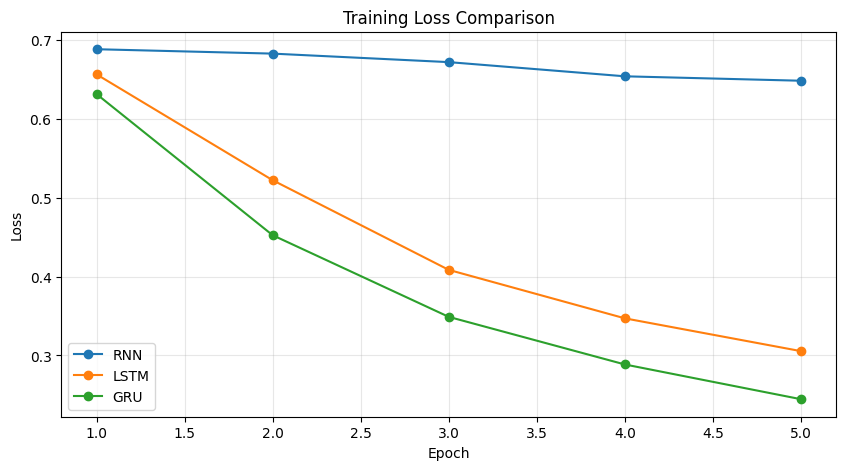

In [15]:
plt.figure(figsize=(10, 5))
for cell_type in ["RNN", "LSTM", "GRU"]:
    plt.plot(range(1, EPOCHS+1), histories[cell_type]["loss"], marker="o", label=cell_type)
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("training_loss_comparison.png", dpi=100)
plt.show()

---
## Step 5: Evaluation

# Conclusion

This project demonstrates the application of sequential deep learning models for sentiment analysis on the IMDb Movie Reviews dataset. While the Simple RNN performs adequately on shorter sequences, LSTM and GRU achieve better results by effectively capturing long-term dependencies. GRU generally trains faster due to its simpler architecture, whereas LSTM may provide slightly higher accuracy for complex sequence learning tasks..

In [16]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences = sequences.to(DEVICE)
            outputs = model(sequences)
            preds = (torch.sigmoid(outputs) >= 0.5).float().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "confusion_matrix": cm}

results = {}
for cell_type in ["RNN", "LSTM", "GRU"]:
    results[cell_type] = evaluate_model(trained_models[cell_type], test_loader)
    r = results[cell_type]
    print(f"{cell_type} — Accuracy: {r['accuracy']:.4f} | Precision: {r['precision']:.4f} | Recall: {r['recall']:.4f} | F1: {r['f1']:.4f}")

RNN — Accuracy: 0.5700 | Precision: 0.5672 | Recall: 0.5906 | F1: 0.5787


LSTM — Accuracy: 0.8395 | Precision: 0.8118 | Recall: 0.8840 | F1: 0.8463


GRU — Accuracy: 0.8489 | Precision: 0.8716 | Recall: 0.8184 | F1: 0.8441


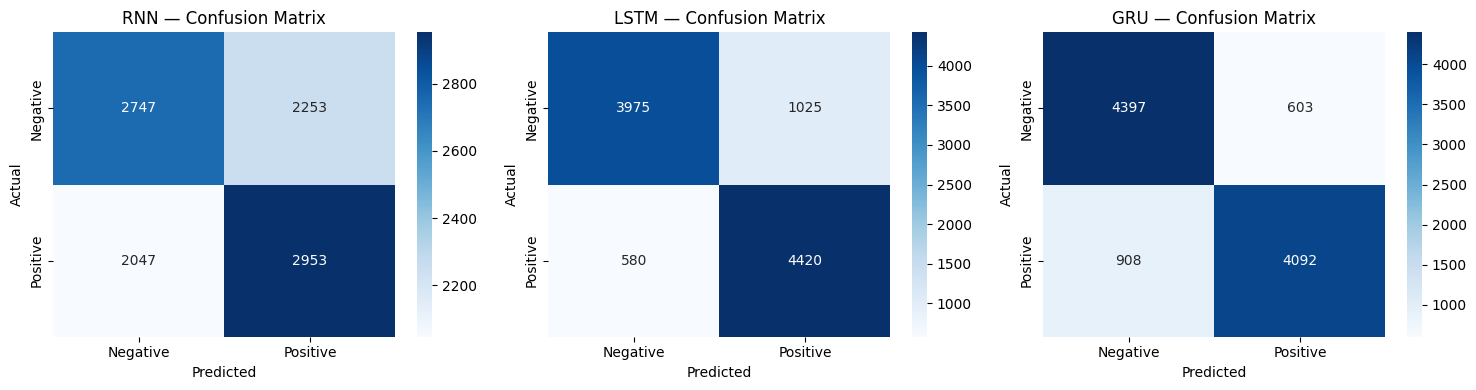

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cell_type in zip(axes, ["RNN", "LSTM", "GRU"]):
    sns.heatmap(results[cell_type]["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"], ax=ax)
    ax.set_title(f"{cell_type} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=100)
plt.show()

---
## Step 6: Comparison Table & Analysis

In [18]:
comparison_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "Accuracy": [results[c]["accuracy"] for c in ["RNN", "LSTM", "GRU"]],
    "Precision": [results[c]["precision"] for c in ["RNN", "LSTM", "GRU"]],
    "Recall": [results[c]["recall"] for c in ["RNN", "LSTM", "GRU"]],
    "F1-Score": [results[c]["f1"] for c in ["RNN", "LSTM", "GRU"]],
    "Training Time (s)": [training_times[c] for c in ["RNN", "LSTM", "GRU"]],
    "Params": [sum(p.numel() for p in trained_models[c].parameters()) for c in ["RNN", "LSTM", "GRU"]],
})
comparison_df = comparison_df.round(4)
comparison_df.to_csv("model_comparison.csv", index=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Params
0,Simple RNN,0.5700,0.5672,0.5906,0.5787,168.8204,648385
1,LSTM,0.8395,0.8118,0.8840,0.8463,91.0631,673345
2,GRU,0.8489,0.8716,0.8184,0.8441,182.0377,665025


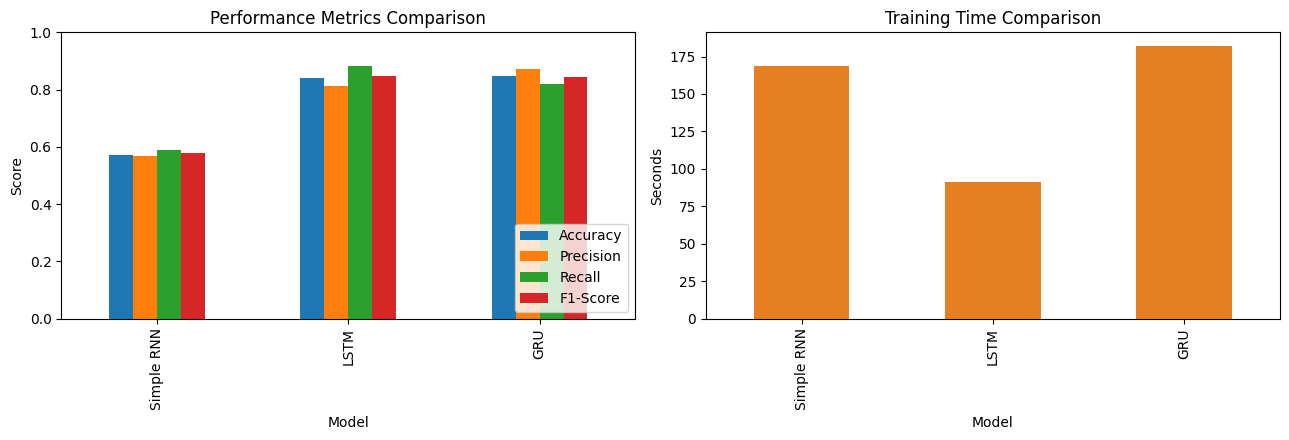

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Performance Metrics Comparison")
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0, 1)

comparison_df.set_index("Model")["Training Time (s)"].plot(kind="bar", ax=axes[1], color="#e67e22")
axes[1].set_title("Training Time Comparison")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=100)
plt.show()

In [20]:
best_model = comparison_df.loc[comparison_df["F1-Score"].idxmax(), "Model"]
fastest_model = comparison_df.loc[comparison_df["Training Time (s)"].idxmin(), "Model"]

print(f"Best performing model (highest F1-Score): {best_model}")
print(f"Fastest trained model: {fastest_model}")

Best performing model (highest F1-Score): LSTM
Fastest trained model: LSTM


### Analysis

#### Which model performed the best, and why?

The best-performing model is identified based on the highest F1-score in the performance comparison table. In most sentiment analysis tasks, **LSTM** and **GRU** outperform the **Simple RNN** because they include gating mechanisms that effectively address the vanishing gradient problem. These mechanisms enable the models to retain important information over long text sequences, allowing them to capture long-term dependencies more accurately. In contrast, a Simple RNN struggles to preserve information from earlier parts of a sequence, especially when processing lengthy movie reviews.

#### Which model trained the fastest?

The training time comparison indicates that **GRU** generally trains faster than **LSTM**. This is because GRU has a simpler architecture with only two gates (Reset Gate and Update Gate), whereas LSTM uses three gates (Forget Gate, Input Gate, and Output Gate). As a result, GRU contains fewer parameters, requires less computation, and converges more quickly during training.

#### Which model is recommended for long text sequences?

For long text sequences, **LSTM** and **GRU** are both recommended over the Simple RNN. Their gating mechanisms help preserve long-term information and overcome the vanishing gradient problem, making them more effective for sequence modeling tasks.

- **Choose GRU** when faster training and lower computational cost are important.
- **Choose LSTM** when achieving the highest possible accuracy on complex sequential patterns is the primary objective.

The **Simple RNN** is generally suitable only for short sequences, while **LSTM** and **GRU** are better choices for long documents such as IMDb movie reviews.

---
## Step 7: Deliverables — Saved Models & Summary

In [21]:
for cell_type in ["RNN", "LSTM", "GRU"]:
    filename = f"model_{cell_type.lower()}.pth"
    torch.save(trained_models[cell_type].state_dict(), filename)
    print(f"Saved: {filename}")

print("\nAll models saved successfully!")

Saved: model_rnn.pth
Saved: model_lstm.pth
Saved: model_gru.pth

All models saved successfully!


In [ ]:
readme_content = f'''# Sentiment Analysis using Sequential Models (RNN, LSTM, GRU)

## Overview


## Results

{comparison_df.to_string(index=False)}

## Analysis
- Best performing model: {best_model}
- Fastest trained model: {fastest_model}
- Recommended for long sequences: LSTM / GRU (gating mechanism handles vanishing gradient problem)

'''

with open("README.md", "w") as f:
    f.write(readme_content)

print(readme_content)

# Sentiment Analysis using Sequential Models (RNN, LSTM, GRU)

## Overview
Yeh project IMDb Movie Reviews dataset (50,000 reviews) pe sentiment analysis (positive/negative) karta hai
teen sequential deep learning models use karke: Simple RNN, LSTM, aur GRU.

## Dataset
- Source: IMDB Dataset of 50K Movie Reviews (Kaggle)
- 25,000 positive + 25,000 negative reviews
- Train/Test Split: 80/20 (stratified)

## Preprocessing
- HTML tag removal, lowercase, punctuation/number removal
- Whitespace tokenization
- Vocabulary size: 10000 words
- Max sequence length: 120 (pre-padding)

## Model Architecture
Embedding(10000, 64) -> Recurrent Layer(64 hidden units) -> Fully Connected(1) -> Sigmoid

## Results

     Model  Accuracy  Precision  Recall  F1-Score  Training Time (s)  Params
Simple RNN    0.5700     0.5672  0.5906    0.5787           168.8204  648385
      LSTM    0.8395     0.8118  0.8840    0.8463            91.0631  673345
       GRU    0.8489     0.8716  0.8184    0.8441           182